In [34]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
import seaborn as sns


seed = 1234
np.random.seed(seed)


In [52]:
# read data
data = pd.read_csv('diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv')
# save original dataset
original_data = data.copy()

features_to_drop = ['weight', 'payer_code', 'medical_specialty']
data = data.drop(features_to_drop, axis=1)
# data['medical_specialty'] = data['medical_specialty'].replace('?', 'Missing')
data = data.replace('?', np.nan)

#dropping rows with missing race for now
data = data.dropna(subset='race')
data['diag_1'] = pd.to_numeric(data['diag_1'], errors='coerce')

data['diag_1'] = data['diag_1'].fillna('Missing')

data['diag_2'] = pd.to_numeric(data['diag_2'], errors='coerce')

data['diag_2'] = data['diag_2'].fillna('Missing')

data['diag_3'] = pd.to_numeric(data['diag_3'], errors='coerce')

data['diag_3'] = data['diag_3'].fillna('Missing')
data.drop_duplicates(['patient_nbr'], keep = 'first', inplace = True)

print(len(data))

intervalDict = {'[0-10)' : 5,
'[10-20)' : 15,
'[20-30)' : 25,
'[30-40)' : 35,
'[40-50)' : 45,
'[50-60)' : 55,
'[60-70)' : 65,
'[70-80)' : 75,
'[80-90)' : 85,
'[90-100)' : 95}

data['age'] = data['age'].apply(lambda x : intervalDict[x])

# 1 = Emergency/Urgent, 5 = Not Available/NULL/Not Mapped, 3 = Elective, 4 = Newborn, 7 = Trauma Center
data['admission_type_id'] = data['admission_type_id'].apply(lambda x : 1 if int(x) in [1, 2]
                                                            else (5 if int(x) in [5, 6, 8]
                                                                  else int(x) ))
# 1 = Referral, 2 = Transfer, 3 = Nan, 4 = Delivery, etc.
data['admission_source_id'] = data['admission_source_id'].apply(lambda x : 1 if int(x) in [2, 3]
                                                                else (2 if int(x) in [4, 5, 6, 10, 22, 25]
                                                                      else (3 if int(x) in [9, 15, 17, 20, 21]
                                                                            else (4 if int(x) in [11, 13, 14]
                                                                                  else int(x)))))

# discharge disposition categorization
data['discharge_disposition_id'] = data['discharge_disposition_id'].apply(
    lambda x: 1 if int(x) in [6, 8, 9, 13]
    else (2 if int(x) in [3, 4, 5, 14, 22, 23, 24]  # discharged to facility
    else (10 if int(x) in [12, 15, 16, 17]          # hospice
    else (11 if int(x) in [19, 20, 21]              # expired
    else (18 if int(x) in [25, 26]                  # psychiatric
      else int(x)))))
)

# remove patients that died or hospice related
data = data[~data.discharge_disposition_id.isin([11,13,14,19,20,21])]



# diagnostic categorization
def categorize_diagnosis(diag):

    if diag == 'Missing':
        return 'Missing'

    try:
        diag = float(diag)
    except:
        return 'Other'

    if 390 <= diag <= 459 or diag == 785:
        return 'Circulatory'
    elif 460 <= diag <= 519 or diag == 786:
        return 'Respiratory'
    elif 520 <= diag <= 579 or diag == 787:
        return 'Digestive'
    elif 250 <= diag < 251:
        return 'Diabetes'
    elif 800 <= diag <= 999:
        return 'Injury'
    elif 710 <= diag <= 739:
        return 'Musculoskeletal'
    elif 580 <= diag <= 629 or diag == 788:
        return 'Genitourinary'
    elif 140 <= diag <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

data['diag_1_cat'] = data['diag_1'].apply(categorize_diagnosis)
data['diag_2_cat'] = data['diag_2'].apply(categorize_diagnosis)
data['diag_3_cat'] = data['diag_3'].apply(categorize_diagnosis)
data = data.drop(['diag_1', 'diag_2', 'diag_3'], axis=1) # dropping the original columns bc new ones were created

# response variable
data['readmitted'] = data['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
data['change'] = data['change'].apply(lambda x : 1 if x == 'Ch'
                                                 else 0)


data['diabetesMed'] = data['diabetesMed'].apply(lambda x : 0 if x == 'No'
                                                else 1)

for col in ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton", "insulin", "glyburide-metformin", "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone"]:
    data[col] = data[col].apply(lambda x : 1 if x == 'Up'
            else ( -1 if x == 'Down'
            else ( 0 if x == 'Steady'
            else  -2)))


data['max_glu_serum'] = data['max_glu_serum'].apply(lambda x : 200 if x == '>200'
                                                            else ( 300 if x == '>300'
                                                            else ( 100 if x == 'Norm'
                                                            else  0)))

data['A1Cresult'] = data['A1Cresult'].apply(lambda x : 7 if x == '>7'
                                                         else (8 if  x == '>8'
                                                         else ( 5 if x == 'Norm'
                                                         else  0)))

data = pd.get_dummies(data, columns=['admission_type_id','admission_source_id', 'gender', 'race'])
data = data.drop(['encounter_id', 'patient_nbr'], axis=1)
data.head()
# print(len(data))

69668


,age,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,admission_source_id_7,admission_source_id_8,gender_Female,gender_Male,gender_Unknown/Invalid,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,race_Other
0,5,18,1,41,0,1,0,0,0,1,...,False,False,True,False,False,False,False,True,False,False
1,15,1,3,59,0,18,0,0,0,9,...,True,False,True,False,False,False,False,True,False,False
2,25,1,2,11,5,13,2,0,1,6,...,True,False,True,False,False,True,False,False,False,False
3,35,1,2,44,1,16,0,0,0,7,...,True,False,False,True,False,False,False,True,False,False
4,45,1,1,51,0,8,0,0,0,5,...,True,False,False,True,False,False,False,True,False,False


In [54]:
# split test/train

# separate features and target
X = data.drop("readmitted", axis=1)
y = data["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

# splitting into test and validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=seed, stratify=y_train)

print(X.shape)
print(X.columns)
# verify the shape
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(68609, 59)
Index(['age', 'discharge_disposition_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_cat',
       'diag_2_cat', 'diag_3_cat', 'admission_type_id_1',
       'admission_type_id_3', 'admission_type_id_4', 'admission_type_id_5',
       'admission_type_id_7', 'admission_source_id_1', 'admission_source_id_2',
       'admission_source_id_3', 'admission_sourc

Threshold tuning on validation set:
  Threshold 0.2: Accuracy=0.8893, F1=0.1122
  Threshold 0.25: Accuracy=0.9026, F1=0.0773
  Threshold 0.3: Accuracy=0.9064, F1=0.0432
  Threshold 0.35: Accuracy=0.9084, F1=0.0233
  Threshold 0.4: Accuracy=0.9092, F1=0.0142
  Threshold 0.45: Accuracy=0.9096, F1=0.0080
  Threshold 0.5: Accuracy=0.9100, F1=0.0048

Best threshold: 0.2 (F1=0.1122)

Neural Network Test Accuracy: 0.8909

Classification Report:
                 precision    recall  f1-score   support

 Not Readmitted       0.91      0.97      0.94     12489
Readmitted <30d       0.22      0.08      0.12      1233

       accuracy                           0.89     13722
      macro avg       0.57      0.53      0.53     13722
   weighted avg       0.85      0.89      0.87     13722



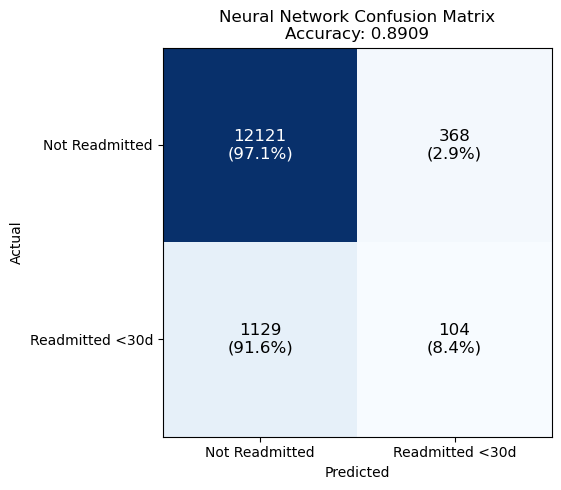

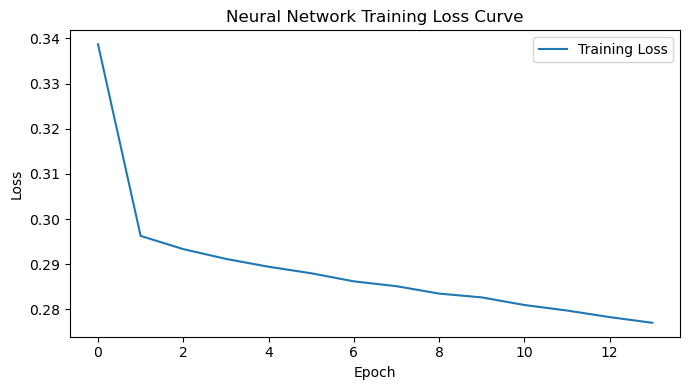


Architecture : input(59) -> hidden(64, ReLU) -> hidden(32, ReLU) -> output(sigmoid)
Epochs run   : 14
Best val score: 0.9101
Decision threshold: 0.2


In [55]:
# NN with 2 hiddewn layers
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Encode remaining string columns (diag_1_cat, diag_2_cat, diag_3_cat)
for col in X_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col]   = le.transform(X_val[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# input -> hidden(64, ReLU) -> hidden(32, ReLU) -> output
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=seed,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=False
)

mlp.fit(X_train_scaled, y_train)

# tune threshold on validation set — pick best F1
y_val_prob = mlp.predict_proba(X_val_scaled)[:, 1]
print("Threshold tuning on validation set:")
best_threshold = 0.5
best_f1 = 0

for threshold in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    y_val_pred = (y_val_prob >= threshold).astype(int)
    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred)
    print(f"  Threshold {threshold}: Accuracy={acc:.4f}, F1={f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nBest threshold: {best_threshold} (F1={best_f1:.4f})")

y_prob = mlp.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

acc = accuracy_score(y_test, y_pred)
print(f"\nNeural Network Test Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted <30d']))

# confusion matrix with percentages
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Readmitted', 'Readmitted <30d'])
ax.set_yticklabels(['Not Readmitted', 'Readmitted <30d'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Neural Network Confusion Matrix\nAccuracy: {acc:.4f}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)',
                ha='center', va='center', fontsize=12,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

# Training loss curve
plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Neural Network Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

n_features = X_train.shape[1]
print(f"\nArchitecture : input({n_features}) -> hidden(64, ReLU) -> hidden(32, ReLU) -> output(sigmoid)")
print(f"Epochs run   : {mlp.n_iter_}")
print(f"Best val score: {mlp.best_validation_score_:.4f}")
print(f"Decision threshold: {best_threshold}")

In [56]:
# kNN classifier
# need to encode categorical columns into numbers
# one hot encoding is required
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# dividing the columns to categorical
categor_cols = ['age', 'max_glu_serum', 'A1Cresult',
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone',
    'change', 'diabetesMed',
    'diag_1_cat', 'diag_2_cat', 'diag_3_cat']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# we want to apply encoding only to categorical columns
preprocessor = ColumnTransformer(transformers=[('cat', encoder, categor_cols)], remainder='passthrough')

scaler = StandardScaler()

# remove id cols
# X_train_small = X_train.drop(columns=['encounter_id', 'patient_nbr'])
# X_val_small = X_val.drop(columns=['encounter_id', 'patient_nbr'])
# encode x_train
X_train_encoded = preprocessor.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_encoded = preprocessor.transform(X_val)
X_val_scaled = scaler.transform(X_val_encoded)

k_values = [1, 2, 3, 4, 5, 10, 13, 15, 20, 30]
accuracy_array = []
f1_array = []
for i in range(len(k_values)):
    k = k_values[i]
    knn_classifier = KNeighborsClassifier(n_neighbors=k)
    # fit on the training data
    knn_classifier.fit(X_train_scaled, y_train)

    # make predictions on validation test
    y_val_pred = knn_classifier.predict(X_val_scaled)

    # compare predictions to validation labels
    accuracy_val = accuracy_score(y_val, y_val_pred)
    f1_score_val = f1_score(y_val, y_val_pred)
    accuracy_array.append(accuracy_val)
    f1_array.append(f1_score_val)

for i in range(len(k_values)):
    print("k =", k_values[i], "-> Accuracy:", accuracy_array[i], ", F1:", f1_array[i])

print("kNN's best accuracy is 91%. However, it's due to the class imbalance")
print("I choose k = 1 with 84% accuracy because it's F1 score is the highest 0.09")

k = 1 -> Accuracy: 0.8417140358548316 , F1: 0.10617283950617284
k = 2 -> Accuracy: 0.9035126074916193 , F1: 0.027900146842878122
k = 3 -> Accuracy: 0.8930913860953213 , F1: 0.05659163987138264
k = 4 -> Accuracy: 0.9073021425448186 , F1: 0.017001545595054096
k = 5 -> Accuracy: 0.904824369625419 , F1: 0.025373134328358207
k = 10 -> Accuracy: 0.9102171695088179 , F1: 0.004846526655896607
k = 13 -> Accuracy: 0.910071418160618 , F1: 0.0032310177705977385
k = 15 -> Accuracy: 0.909998542486518 , F1: 0.003228410008071025
k = 20 -> Accuracy: 0.910071418160618 , F1: 0.0
k = 30 -> Accuracy: 0.910071418160618 , F1: 0.0
kNN's best accuracy is 91%. However, it's due to the class imbalance
I choose k = 1 with 84% accuracy because it's F1 score is the highest 0.09


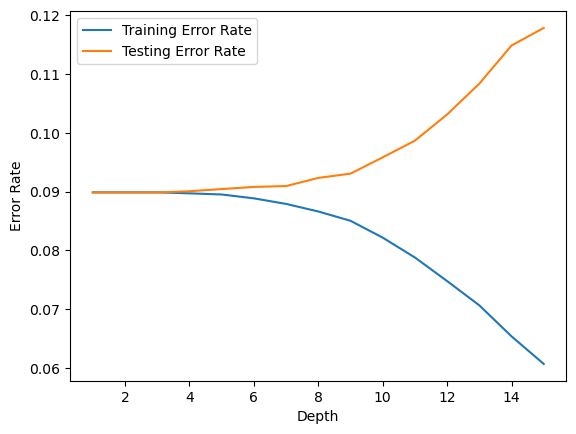

In [58]:
X_train_small = pd.get_dummies(X_train, columns=['diag_1_cat', 'diag_2_cat', 'diag_3_cat'])
X_val_small = pd.get_dummies(X_val, columns=['diag_1_cat', 'diag_2_cat', 'diag_3_cat'])
X_test_small = pd.get_dummies(X_val, columns=['diag_1_cat', 'diag_2_cat', 'diag_3_cat'])

feature_names = X_train_small.columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_small)
X_val_scaled   = scaler.transform(X_val_small)
X_test_scaled  = scaler.transform(X_test_small)


train_array = []
test_array = []

for i in range(1, 16):
    classifier = DecisionTreeClassifier(max_depth=i)
    classifier.fit(X_train, y_train)
    y_te_predict = classifier.predict(X_test)
    y_tr_predict = classifier.predict(X_train)
    test_accuracy = accuracy_score(y_test, y_te_predict)
    train_accuracy = accuracy_score(y_train, y_tr_predict)
    train_array.append(1 - train_accuracy)
    test_array.append(1 - test_accuracy)

plt.plot(list(range(1, 16)), train_array, label="Training Error Rate")
plt.plot(list(range(1, 16)), test_array, label="Testing Error Rate")
plt.xlabel("Depth")
plt.ylabel("Error Rate")
plt.legend()


test accuracy 0.8283777874945343, train accuracy 1.0


Text(0.5, 1.0, 'Feature Importance in Decision Tree Classifier')

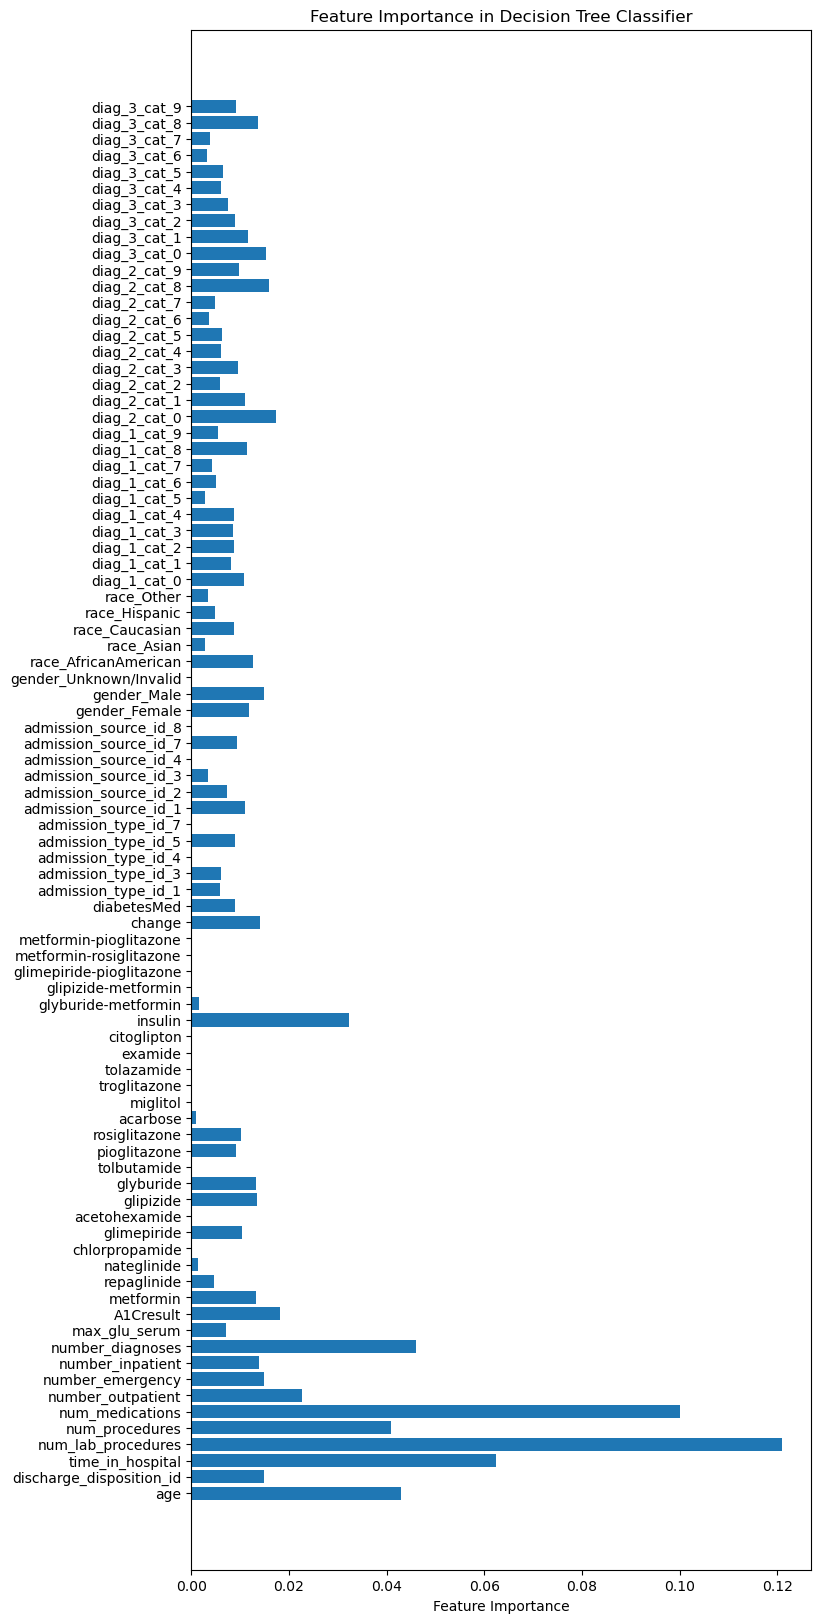

In [59]:
classifier = DecisionTreeClassifier(max_depth=50)
classifier.fit(X_train_scaled, y_train)
y_te_predict = classifier.predict(X_val_scaled)
y_tr_predict = classifier.predict(X_train_scaled)
test_accuracy = accuracy_score(y_val, y_te_predict)
train_accuracy = accuracy_score(y_train, y_tr_predict)
print(f"test accuracy {test_accuracy}, train accuracy {train_accuracy}")

feature_importances = classifier.feature_importances_
plt.figure(figsize=(8, 20))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Decision Tree Classifier')

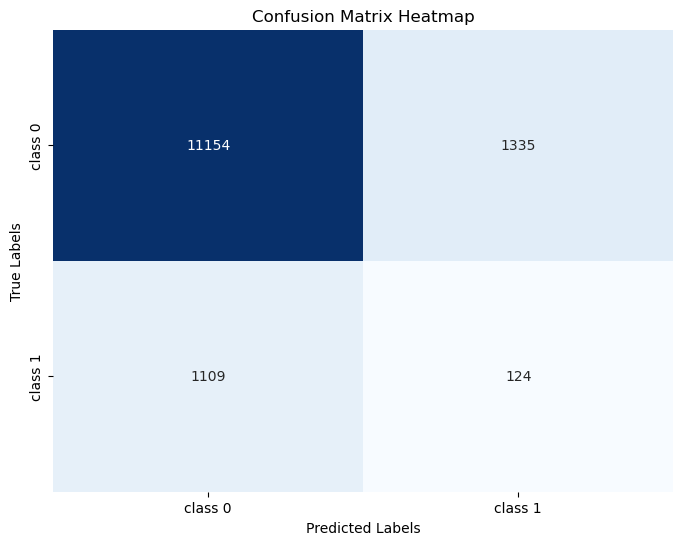

In [60]:
conf_matrix = confusion_matrix(y_test, y_te_predict)
target_names = ['class 0', 'class 1']
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=target_names, yticklabels=target_names)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Accuracy: 91.02%


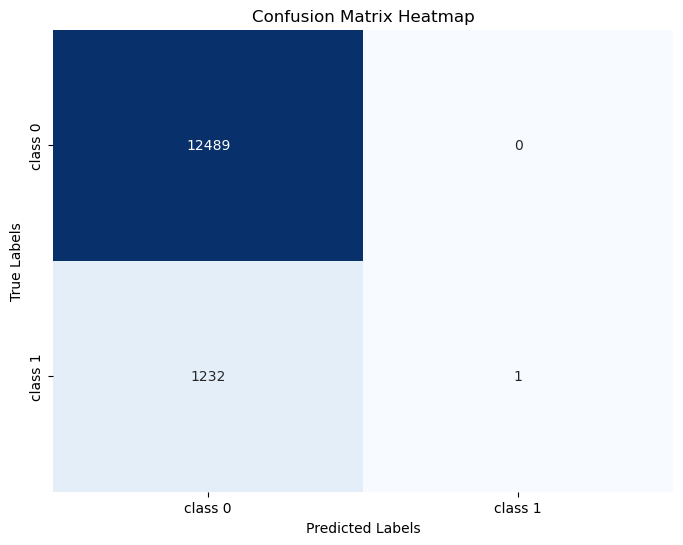

In [61]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=60, )
classifier.fit(X_train_scaled, y_train)
y_pred = classifier.predict(X_val_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

conf_matrix = confusion_matrix(y_test, y_pred)
target_names = ['class 0', 'class 1']
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=target_names, yticklabels=target_names)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


Text(0.5, 1.0, 'Feature Importance in Random Forest Classifier')

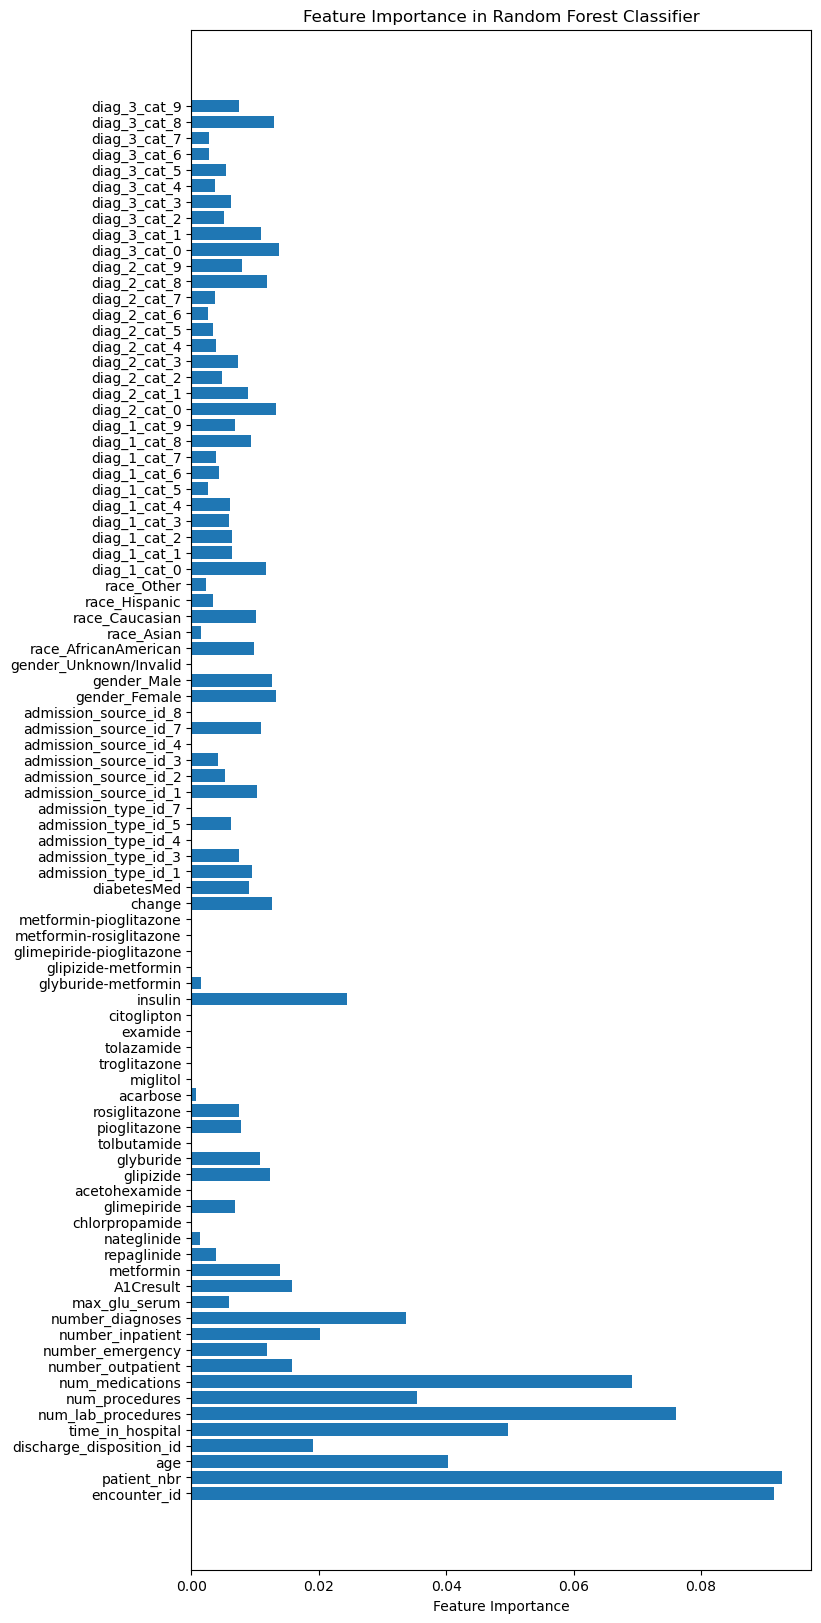

In [46]:
feature_importances = classifier.feature_importances_
plt.figure(figsize=(8, 20))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
# plt.show()